# Atividade de vendas no Brasil

In [46]:
#imports

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

# Entregável 1 NumPy

In [47]:
df_vendas = pd.read_csv('../../data/vendas_brasil_1.csv')

df_vendas

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37612,2023-12-31,3,Porto Alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,Bronze,73.11,47.38,...,9,20.3,524.49,8.15,4.95,NaN,False,False,False,False
37613,2023-12-31,9,Salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,...,12,10.7,820.52,41.74,4.49,19.0,False,False,False,False
37614,2023-12-31,2,Salvador,Loja Física,Alimentação,Whey Protein,Fábio Ramos,Bronze,55.15,36.94,...,7,0.0,384.44,85.35,4.02,14.0,False,True,False,False
37615,2023-12-31,11,São Paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,...,7,10.9,1960.18,30.99,3.50,6.0,False,True,True,False


### A. Criando arrays

In [48]:
arr_preco_unitario = np.array(df_vendas['preco_unitario'])
arr_custo_unitario = np.array(df_vendas['custo_unitario'])
arr_desconto_pct = np.array(df_vendas['desconto_pct'])
arr_receita_total = np.array(df_vendas['receita_total'])
arr_frete = np.array(df_vendas['frete'])
arr_quantidade = np.array(df_vendas['quantidade'])

print(arr_preco_unitario)
print(arr_custo_unitario)
print(arr_desconto_pct)
print(arr_receita_total)
print(arr_frete)
print(arr_quantidade)

[ 739.39  187.48   76.11 ...   55.15  197.09 1057.41]
[561.75 135.15  61.4  ...  36.94 167.23 870.69]
[ 5.2  0.6  0.7 ...  0.  10.9 10. ]
[6933.48  930.28 1058.5  ...  384.44 1960.18 3795.73]
[ 8.68   nan  7.98 ... 85.35 30.99 27.23]
[10  5 14 ...  7  7  4]


### B. Cálculos com operações vetorizadas

In [49]:
valor_bruto = arr_preco_unitario * arr_quantidade
valor_desconto = arr_preco_unitario * arr_quantidade * (arr_desconto_pct / 100)
custo_total = arr_custo_unitario * arr_quantidade
lucro_estimado = valor_bruto - valor_desconto - custo_total

print(valor_bruto)
print(valor_desconto)
print(custo_total)
print(lucro_estimado)

[7393.9   937.4  1065.54 ...  386.05 1379.63 4229.64]
[384.4828    5.6244    7.45878 ...   0.      150.37967 422.964  ]
[5617.5   675.75  859.6  ...  258.58 1170.61 3482.76]
[1391.9172   256.0256   198.48122 ...  127.47      58.64033  323.916  ]


### C. Máscaras booleanas

In [50]:
receitas_acima_media = arr_receita_total > arr_receita_total.mean()
vendas_prejuizo = lucro_estimado < 0
vendas_desconto_alto = arr_desconto_pct > arr_desconto_pct.mean()

print(np.sum(receitas_acima_media))
print(np.sum(vendas_prejuizo))
print(np.sum(vendas_desconto_alto))

9236
2857
17853


### D. Agregações

In [51]:
receita_media = arr_receita_total.mean()
maior_receita = arr_receita_total.max()
menor_receita = arr_receita_total.min()
lucro_medio = lucro_estimado.mean()
qtd_vendas_prejuizo = vendas_prejuizo.sum()

print(receita_media)
print(maior_receita)
print(menor_receita)
print(lucro_medio)
print(qtd_vendas_prejuizo)

1891.6881729005502
58430.28
3.7
342.0324771624531
2857


### conclusao

dando uma olhada nos numeros da pra ver que boa parte das vendas fica acima da media, o que ja era esperado. o que mais chamou atencao foi a quantidade de vendas com prejuizo, tem bastante caso onde o desconto mais o custo comeu o valor da venda inteiro. usar numpy vetorizado foi bem mais rapido que ficar rodando linha por linha

# Entregável 2 Pandas

### A. Primeiro olhar no dataset

In [61]:
print(df_vendas.head())
print(df_vendas.info())
print(df_vendas.describe())
print(df_vendas.shape)
print(df_vendas.isna().sum())

  data_venda  mes          cidade canal_venda    categoria      produto  \
0 2022-04-13    4  Rio de Janeiro  App Mobile  Eletrônicos     Notebook   
1 2023-12-03    3          Manaus    Site Web    Vestuário     Camiseta   
2 2022-09-28    9         Goiânia  App Mobile    Vestuário        Tênis   
3 2022-04-17    4       Fortaleza    Site Web    Vestuário  Calça Jeans   
4 2022-03-13    3  Belo Horizonte  App Mobile     Esportes    Bicicleta   

       vendedor fidelidade_cliente  preco_unitario  custo_unitario  ...  \
0   Bruno Souza           Diamante          739.39          561.75  ...   
1   Elisa Costa             Bronze          187.48          135.15  ...   
2   João Vieira             Bronze           76.11           61.40  ...   
3  Carla Mendes             Bronze          145.86           88.53  ...   
4   João Vieira             Bronze          133.92          107.25  ...   

   prazo_entrega_dias  devolucao  entrega_no_prazo  alta_temporada  \
0            5.000000      F

### 1. quantas linhas e colunas existem?
- 21 colunas e 37617 linhas

### 2. Existem dados faltantes?
-   sim

### 3. quais colunas parecem numericas?
- mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct,receita_total,frete, avaliacao_cliente, prazo_entrega_dias  

### 4. quais colunas parecem ser categóricas?
- data venda,cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente

### B. Limpeza e tratamento

In [53]:
#converte data-datetime
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'], format='mixed', dayfirst=True)


df_vendas['cidade'].unique()

#normaliza

df_vendas['cidade'] = df_vendas['cidade'].str.strip().str.title()
    #mapeia os erros
correcoes_cidade = {
    'Sp': 'São Paulo',
    'S. Paulo': 'São Paulo',
    'Sao Paulo': 'São Paulo',
    'São Paulo ': 'São Paulo',
    'Bh': 'Belo Horizonte',
    'B. Horizonte': 'Belo Horizonte',
    'Rio': 'Rio de Janeiro',
    'Rio De Janeiro': 'Rio de Janeiro',
    'Rio De janeiro': 'Rio de Janeiro',
    'Curtiba': 'Curitiba',
    'Slavador': 'Salvador',
    'Rj': 'Rio de Janeiro',
}

correcoes_canal = {
    'App Mobile': 'App Mobile',
    'APP Mobile': 'App Mobile',
    'app mobile': 'App Mobile',
    'App mobile': 'App Mobile',
    'Site Web': 'Site Web',
    'site web': 'Site Web',
    'Site web': 'Site Web',
    'SiteWeb': 'Site Web',
    'Loja Física': 'Loja Física',
    'loja física': 'Loja Física',
    'Loja Fisica': 'Loja Física',
    'Loja fisica': 'Loja Física',
    'Marketplace': 'Marketplace',
    'Televendas': 'Televendas',
    'Desconhecido': 'Desconhecido',
}
df_vendas['cidade'] = df_vendas['cidade'].replace(correcoes_cidade)
df_vendas['canal_venda'] = df_vendas['canal_venda'].replace(correcoes_canal)

sorted(df_vendas['cidade'].unique())




#trata os nulos
colunas_com_nulos = df_vendas.columns[df_vendas.isna().any()]
print(colunas_com_nulos)

valores_fillna = {
    'canal_venda': 'Desconhecido',
    'vendedor': 'Desconhecido',
    'margem_pct': 0,
    'frete': df_vendas['frete'].mean(),
    'avaliacao_cliente': df_vendas['avaliacao_cliente'].mean(),
    'prazo_entrega_dias': df_vendas['prazo_entrega_dias'].mean(),
}

df_vendas.fillna(valores_fillna, inplace=True)





Index(['canal_venda', 'vendedor', 'margem_pct', 'frete', 'avaliacao_cliente',
       'prazo_entrega_dias'],
      dtype='str')


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.680000,4.92,5.000000,False,True,False,False
1,2023-12-03,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,29.885737,4.98,19.000000,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.980000,3.47,10.017113,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.490000,4.50,16.000000,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.890000,3.49,13.000000,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37612,2023-12-31,3,Porto Alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,Bronze,73.11,47.38,...,9,20.3,524.49,8.150000,4.95,10.017113,False,False,False,False
37613,2023-12-31,9,Salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,...,12,10.7,820.52,41.740000,4.49,19.000000,False,False,False,False
37614,2023-12-31,2,Salvador,Loja Física,Alimentação,Whey Protein,Fábio Ramos,Bronze,55.15,36.94,...,7,0.0,384.44,85.350000,4.02,14.000000,False,True,False,False
37615,2023-12-31,11,São Paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,...,7,10.9,1960.18,30.990000,3.50,6.000000,False,True,True,False


corrige inconcistencias nas colunas de canal e cidade, normalizando os dados, trata os nulos com o que faria mais sentido para calculos posteriores, como: aplicar a media para o prazo de entrega, frete e avalicao do cliente

### C. Criação de novas colunas

In [54]:
df_vendas['dia_venda'] = df_vendas['data_venda'].dt.day
df_vendas['mes_venda'] = df_vendas['data_venda'].dt.month
df_vendas['ano_venda'] = df_vendas['data_venda'].apply(lambda x: x.year)
df_vendas['lucro_estimado'] = lucro_estimado

### D. Filtros

In [ ]:
#Quais vendas tiveram receita acima de determinado valor?
filtro_receita_alta = df_vendas[df_vendas['receita_total'] > 1000]
print(filtro_receita_alta[['cidade', 'categoria', 'receita_total']])
print(len(filtro_receita_alta))

achei bastante venda acima de 1000 reais, mostra que nao e raro ter venda de ticket alto

In [ ]:
#Quais vendas tiveram devolução?
filtro_devolucao = df_vendas[df_vendas['devolucao'] == True]
print(filtro_devolucao[['cidade', 'categoria', 'receita_total']])
print(len(filtro_devolucao))

tem um numero razoavel de venda com devolucao, seria legal ver se alguma categoria concentra mais devolucao que as outras

In [ ]:
#Quais vendas pertencem a uma categoria específica?
filtro_eletronicos = df_vendas[df_vendas['categoria'] == 'Eletrônicos']
print(filtro_eletronicos[['cidade', 'canal_venda', 'receita_total']])
print(len(filtro_eletronicos))

eletronicos sozinho ja e uma boa fatia do dataset, confirma o que ja tinha visto no groupby

### E. Agrupamentos com groupby

In [55]:
# receita por categoria
receita_por_categoria = df_vendas.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)
print(receita_por_categoria)

print(f"\nCategoria com maior receita: {receita_por_categoria.idxmax()}")

# vendas por canal
vendas_por_canal = df_vendas.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False)
print(vendas_por_canal)

print(f"\nCanal com mais vendas: {vendas_por_canal.idxmax()}")

# cidade com maior receita
receita_por_cidade = df_vendas.groupby('cidade')['receita_total'].sum().sort_values(ascending=False)
print(receita_por_cidade)

print(f"\nCidade com maior receita: {receita_por_cidade.idxmax()}")

# categoria com maior lucro

lucro_por_categoria = df_vendas.groupby('categoria')['lucro_estimado'].sum().sort_values(ascending=False)
print(lucro_por_categoria)

print(f"\nCategoria com maior lucro: {lucro_por_categoria.idxmax()}")


categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

Categoria com maior receita: Eletrônicos
canal_venda
Site Web        85091
App Mobile      83839
Loja Física     56705
Marketplace     41707
Televendas      13726
Desconhecido      373
Name: quantidade, dtype: int64

Canal com mais vendas: Site Web
cidade
Recife            7662241.79
Manaus            7459161.23
Fortaleza         7242081.82
Goiânia           7178113.69
Porto Alegre      7048428.17
Curitiba          6993175.07
Salvador          6918656.01
Belo Horizonte    6914747.61
Rio de Janeiro    6880176.34
São Paulo         6862852.27
Name: receita_total, dtype: float64

Cidade com maior receita: Recife
categoria
Eletrônicos    8.141113e+06
Esportes       2.082461e+06
Vestuário      1.232406e+06
Livros         8.126898e+05
Alimentação    5.975651e+05
Name: lucro_estimado, dtype: float64

Categoria com 

### F. Merge

In [56]:
tabela_regioes = pd.DataFrame({
    'cidade': ['Rio de Janeiro', 'São Paulo', 'Belo Horizonte', 'Curitiba',
               'Porto Alegre', 'Salvador', 'Recife', 'Fortaleza',
               'Manaus', 'Goiânia'],
    'regiao': ['Sudeste', 'Sudeste', 'Sudeste', 'Sul',
               'Sul', 'Nordeste', 'Nordeste', 'Nordeste',
               'Norte', 'Centro-Oeste']
})

print(tabela_regioes)

df_vendas = df_vendas.merge(tabela_regioes, on='cidade', how='left')

df_vendas['regiao'].isna().sum()


# analise

receita_por_regiao = df_vendas.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)
print(receita_por_regiao)

print(f"\nRegião com maior receita: {receita_por_regiao.idxmax()}")


vendas_por_regiao = df_vendas.groupby('regiao')['quantidade'].sum().sort_values(ascending=False)
print(vendas_por_regiao)

print(f"\nRegião com mais vendas: {vendas_por_regiao.idxmax()}")

           cidade        regiao
0  Rio de Janeiro       Sudeste
1       São Paulo       Sudeste
2  Belo Horizonte       Sudeste
3        Curitiba           Sul
4    Porto Alegre           Sul
5        Salvador      Nordeste
6          Recife      Nordeste
7       Fortaleza      Nordeste
8          Manaus         Norte
9         Goiânia  Centro-Oeste
regiao
Nordeste        21822979.62
Sudeste         20657776.22
Sul             14041603.24
Norte            7459161.23
Centro-Oeste     7178113.69
Name: receita_total, dtype: float64

Região com maior receita: Nordeste
regiao
Nordeste        85881
Sudeste         82653
Sul             56739
Norte           28236
Centro-Oeste    27932
Name: quantidade, dtype: int64

Região com mais vendas: Nordeste


### conclusao

o dataset veio sujo, tinha nulo e nome de cidade/canal escrito de varios jeitos. tratei os nulos e normalizei os textos. no fim, eletronicos e a categoria que mais fatura e mais lucra, site web e o canal que mais vende, e recife foi a cidade com maior receita

# Entregável 3 Seaborn

### A. Gráfico de barras

/tmp/ipykernel_109722/2609475309.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=receita_categoria.index, y=receita_categoria.values, ax=ax, palette='viridis')


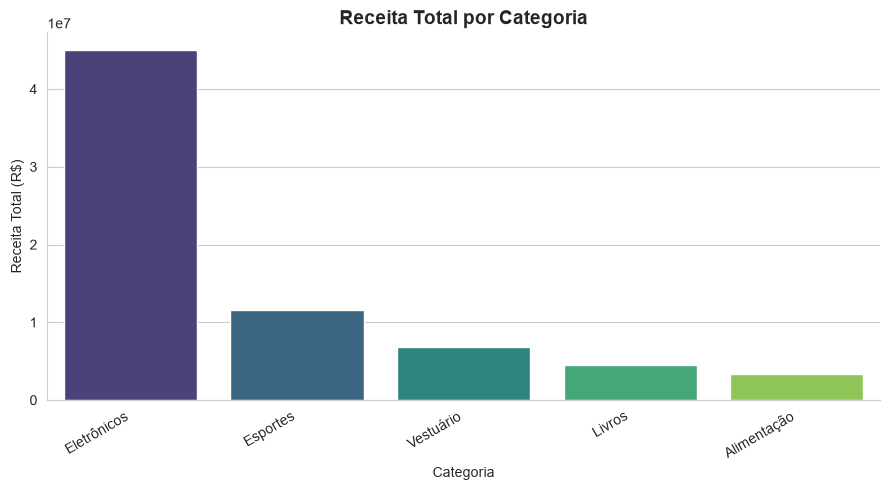

In [57]:
receita_categoria = df_vendas.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=receita_categoria.index, y=receita_categoria.values, ax=ax, palette='viridis')

ax.set_title('Receita Total por Categoria', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria')
ax.set_ylabel('Receita Total (R$)')
plt.xticks(rotation=30, ha='right')
sns.despine()

plt.tight_layout()
plt.show()

**interpretacao:** da pra ver de cara que eletronicos domina, bem na frente de esportes e das outras categorias. a empresa depende bastante dessa categoria

### B. Gráfico de linha

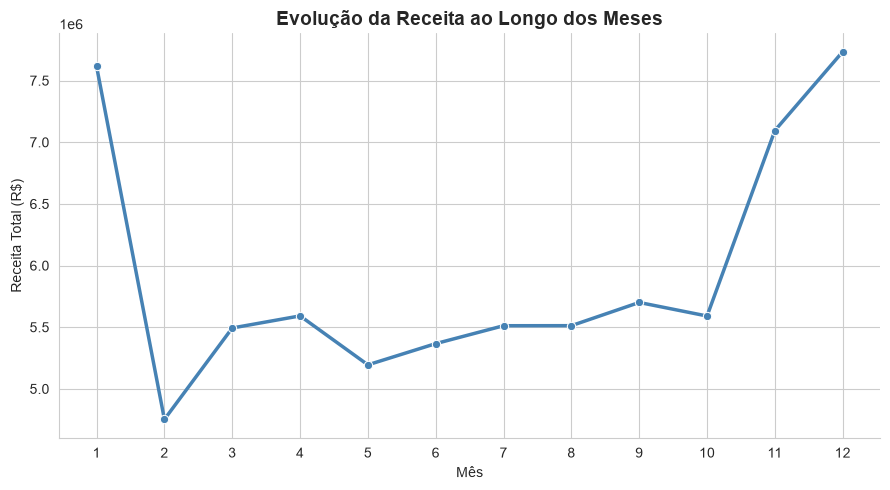

In [58]:
receita_mes = df_vendas.groupby('mes')['receita_total'].sum().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(x=receita_mes.index, y=receita_mes.values, marker='o', linewidth=2.5, ax=ax, color='steelblue')

ax.set_title('Evolução da Receita ao Longo dos Meses', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Receita Total (R$)')
ax.set_xticks(range(1, 13))
sns.despine()

plt.tight_layout()
plt.show()

**interpretacao:** a receita sobe e desce ao longo dos meses, nao e uma linha reta. deve ter a ver com data comemorativa ou promocao em algum periodo

### C. Gráfico de dispersão

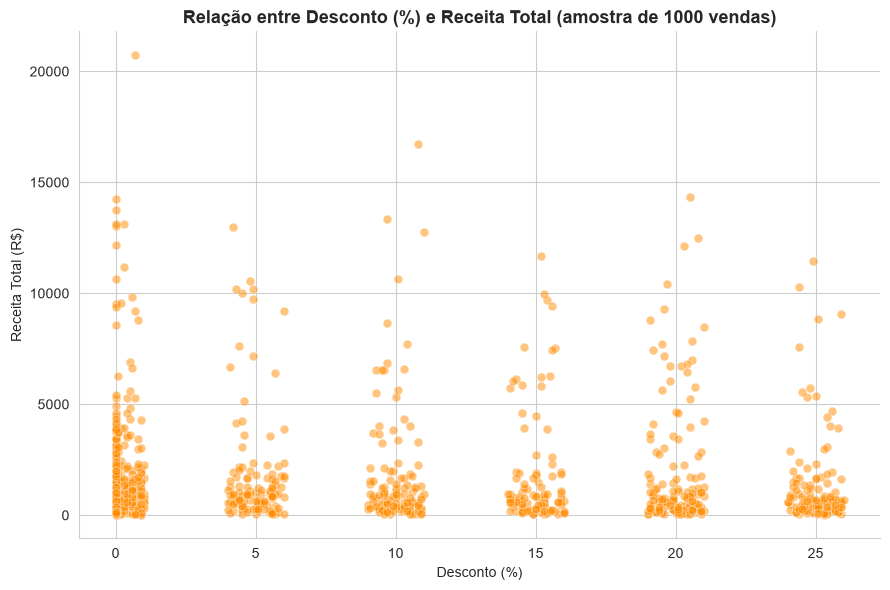

In [59]:
amostra = df_vendas.sample(n=1000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=amostra, x='desconto_pct', y='receita_total', alpha=0.5, s=40, ax=ax, color='darkorange')

ax.set_title('Relação entre Desconto (%) e Receita Total (amostra de 1000 vendas)', fontsize=13, fontweight='bold')
ax.set_xlabel('Desconto (%)')
ax.set_ylabel('Receita Total (R$)')
sns.despine()

plt.tight_layout()
plt.show()

**interpretacao:** olhando o grafico nao da pra dizer que desconto maior significa receita maior ou menor, os pontos estao bem espalhados em todas as faixas. o desconto sozinho nao parece definir o quanto uma venda rende

### D. Mapa de calor

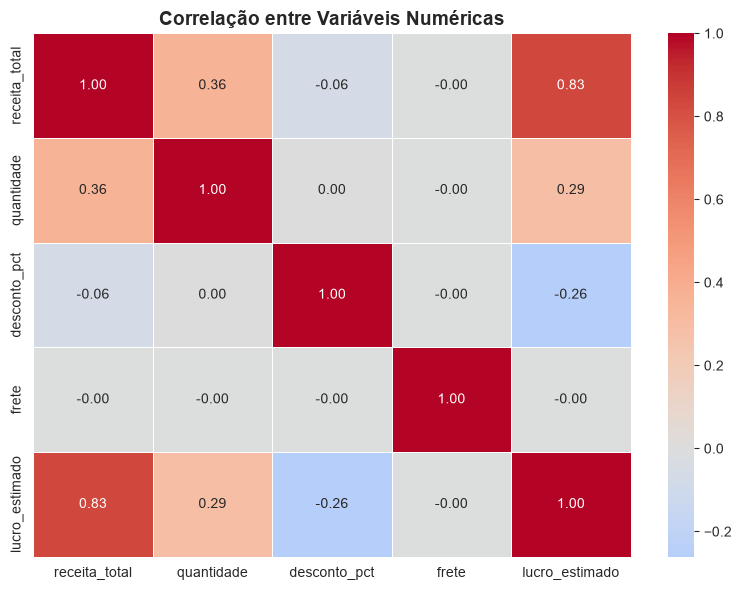

In [60]:
colunas_numericas = ['receita_total', 'quantidade', 'desconto_pct', 'frete', 'lucro_estimado']

corr = df_vendas[colunas_numericas].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)

ax.set_title('Correlação entre Variáveis Numéricas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**interpretacao:** receita e lucro estimado andam bem juntos, faz sentido pq um deriva do outro. as outras variaveis tem correlacao bem mais fraca com o lucro

### conclusao final

juntando tudo que vi nos graficos com o que ja tinha achado na parte de pandas, eletronicos realmente carrega o negocio em receita e lucro, a receita nao e constante mes a mes, e o desconto sozinho nao explica muito sobre o quanto uma venda vai lucrar